In [ ]:
import os
import sys
import glob
import argparse


# Ensure project root is on sys.path when running directly from scripts/.
PROJECT_ROOT = "/home/mhpereir/LWA_analysis"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

import pymc as pm
import arviz as az

from src import config, config_pymc, preprocess, data_io


from typing import Dict, List, Optional


In [13]:
MODEL_VARIATIONS  = config_pymc.model_variations
OUTPUT_POSTERIORS = os.path.join(config.OUTPUT_PATH, "pymc_fits_bothLWA")

ENSEMBLE_LIST = config.ENSEMBLE_LIST

LWA_var = "bothLWA"
REGION  = "pnw_bartusek"
SEASON  = "JJA"


In [ ]:
def open_posterior_file(filepath: str) -> az.InferenceData:
    """Open a PyMC posterior InferenceData from NetCDF."""
    idata = az.from_netcdf(filepath)
    return idata

def select_season_time(da: xr.DataArray, season: Optional[str]) -> xr.DataArray:
    if season is None or season == "ALL":
        return da
    return da.sel(time=da.time.dt.season == season)

# ----------------------------- Helper functions -----------------------------

def posterior_samples(idata: az.InferenceData, var: str) -> np.ndarray:
    """Return 1D numpy array of posterior samples for var."""
    da = idata.posterior[var] #type: ignore
    return da.stack(sample=("chain", "draw")).values.astype("float64")


In [ ]:
idata_era_models    = {}
idata_canesm_models = {}

print("Loading posteriors for all model variations...")
for model_name in MODEL_VARIATIONS:
    idata_era_models[model_name]    = None  
    idata_canesm_models[model_name] = []

    era_file = os.path.join(OUTPUT_POSTERIORS,
        f"pymc_ar1_{model_name}_{LWA_var}_tas_sm_{REGION}_{SEASON}_ERA5.nc"
    )

    can_files = sorted(glob.glob(os.path.join(
        OUTPUT_POSTERIORS, f"pymc_ar1_{model_name}_{LWA_var}_tas_sm_{REGION}_{SEASON}_CanESM5_*.nc"
    )))
    N_members = len(can_files)

    assert N_members == len(ENSEMBLE_LIST), f"Expected {len(ENSEMBLE_LIST)} CanESM members, found {N_members}"
    # Verify all ensemble members are present
    found_members = {os.path.basename(f).split('_')[-1].split('.')[0] for f in can_files}
    missing = set(ENSEMBLE_LIST) - found_members
    assert not missing, f"Missing ensemble members for {model_name}: {missing} \n {found_members}"

    # Load ERA5
    idata_era_models[model_name] = open_posterior_file(era_file)

    # Load CanESM members
    idata_canesm_models[model_name] = [open_posterior_file(f) for f in can_files]

Loading posteriors for all model variations...
['/home/mhpereir/LWA_analysis/results/pymc_fits_bothLWA/pymc_ar1_full_bothLWA_tas_sm_pnw_bartusek_JJA_CanESM5_r10i1p1f1.nc', '/home/mhpereir/LWA_analysis/results/pymc_fits_bothLWA/pymc_ar1_full_bothLWA_tas_sm_pnw_bartusek_JJA_CanESM5_r10i1p2f1.nc', '/home/mhpereir/LWA_analysis/results/pymc_fits_bothLWA/pymc_ar1_full_bothLWA_tas_sm_pnw_bartusek_JJA_CanESM5_r1i1p1f1.nc', '/home/mhpereir/LWA_analysis/results/pymc_fits_bothLWA/pymc_ar1_full_bothLWA_tas_sm_pnw_bartusek_JJA_CanESM5_r1i1p2f1.nc', '/home/mhpereir/LWA_analysis/results/pymc_fits_bothLWA/pymc_ar1_full_bothLWA_tas_sm_pnw_bartusek_JJA_CanESM5_r2i1p1f1.nc', '/home/mhpereir/LWA_analysis/results/pymc_fits_bothLWA/pymc_ar1_full_bothLWA_tas_sm_pnw_bartusek_JJA_CanESM5_r2i1p2f1.nc', '/home/mhpereir/LWA_analysis/results/pymc_fits_bothLWA/pymc_ar1_full_bothLWA_tas_sm_pnw_bartusek_JJA_CanESM5_r3i1p1f1.nc', '/home/mhpereir/LWA_analysis/results/pymc_fits_bothLWA/pymc_ar1_full_bothLWA_tas_sm_pnw_b

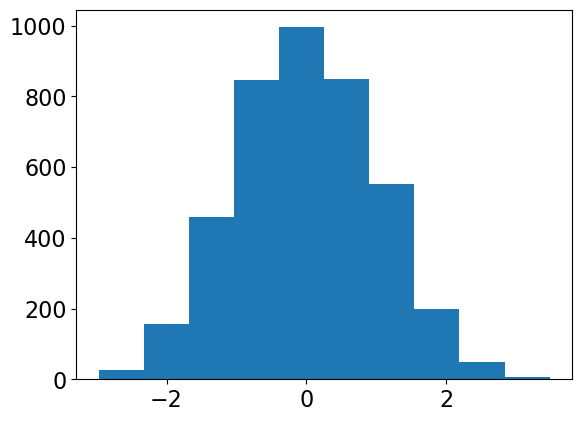

In [24]:
plt.hist(idata_era_models["full"]["observed_data"]["y_like"].values)
plt.show()

In [ ]:
tas_canesm = data_io.open_canesm_temperature(config.TEMP_VAR, ENSEMBLE_LIST)
tas_era5 = data_io.open_era5_temperature(config.TEMP_VAR)

tas_canesm = preprocess.drop_leap_day(preprocess.floor_daily_time(tas_canesm))
tas_era5 = preprocess.drop_leap_day(preprocess.floor_daily_time(tas_era5))

if tas_canesm.sizes["time"] != tas_era5.sizes["time"]:
    raise ValueError("CanESM and ERA5 time lengths do not match after removing leap days.")

tas_canesm_anom = preprocess.dayofyear_anomaly(tas_canesm)
tas_era5_anom = preprocess.dayofyear_anomaly(tas_era5)

tas_canesm_anom = select_season_time(tas_canesm_anom, SEASON)
tas_era5_anom = select_season_time(tas_era5_anom, SEASON)